In [10]:
print("all ok")

all ok


In [6]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [7]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

In [8]:
if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY is missing in your .env")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [9]:
from langchain_openai import ChatOpenAI

In [11]:
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [12]:
chat_llm.invoke("Hello, how are you?").content

"Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"

In [13]:
from typing_extensions import TypedDict, Annotated
import operator

In [14]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [15]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [16]:
{
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [17]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [18]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [19]:
from langgraph.graph import StateGraph

In [20]:
builder = StateGraph(GraphState)

In [21]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [22]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")


In [23]:
app = builder.compile()

In [24]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [25]:
from IPython.display import Image, display

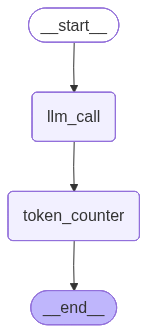

In [26]:
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
})

In [24]:
result

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello, Sunny! It’s a pleasure to meet you. I hope you’re having a wonderful day. How can I assist you today? If you have questions, topics you’d like to discuss, or anything specific on your mind, feel free to share!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 18, 'total_tokens': 70, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DFxFiXOB4kCw7wSmFGUhAPsAnqazi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cbcdb-ef34-75e3-9fcc-6d00c24391d2-0', tool_calls=[],

In [28]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Sunny. Say hello in detail.
AIMessage : Hello, Sunny! It’s a pleasure to meet you. I hope you're having a wonderful day. If there's anything specific you'd like to chat about or any questions you have, feel free to share! Whether it’s a topic of interest, a bit of trivia, or just a friendly conversation, I'm here to help. How can I assist you today?
AIMessage : Total token number in the generated answer (word count) is 58


In [29]:
chat_llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000221B9E43B60>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000221BA357680>, root_client=<openai.OpenAI object at 0x00000221B9EBBC80>, root_async_client=<openai.AsyncOpenAI object at 0x00000221B9E43CE0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [30]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [31]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [32]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [33]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [34]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [35]:
TAVILY_API_KEY

'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'

In [36]:
tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [37]:
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': 'Hiring Flat for the College Class of 2026 - NACE',
  'url': 'https://www.naceweb.org/job-market/trends-and-predictions/hiring-flat-for-the-college-class-of-2026',
  'content': 'Reflecting an uncertain job market for college graduates, employers are projecting just a 1.6% increase in hiring for the Class of 2026 when compared to the Class of 2025, according to results of NACE’s Job Outlook 2026 survey.\n\nThat flat hiring projection is consistent with the tight labor market employers reported at the end of the 2024-25 recruiting year. (See Figure 1.)\n\nThese findings are also consistent with what NACE is seeing with general employment indicators at large. NACE found that employers are less positive about the overall job market for upcoming graduates this year than they were in last several years. Currently, a plurality of employers rate the overall job market for new graduates as "fair," compared to a year ago, when they characterized it as "good." (See Figure 2.) [...] Add

In [38]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [39]:
search.invoke("what is the latest update on iphone17 release?")

"Oct 1, 2025 ·Along with the newiPhone17models, Apple in September released the new-generation Apple Watch Series 11 and Apple Watch Ultra 3, as well as new AirPods Pro 3. 4 days ago ·We've put together everything you need to know about the Apple iPhone 17ereleasedate, specs, and price in time for launch. We covered the Apple event below, and you can read our minute-by-minute account below of all of the company's announcements, along withupdatesas we get some hands-on time with the new phones... Oct 9, 2025 ·Apple has unveiled four newiPhones: theiPhone17, iPhone Air,iPhone17Pro and iPhone17Pro Max. Here’s the lowdown on the specs, price, new features, design, dimensions and more. Sep17, 2025 ·TheiPhone 17lineup has officially arrived, bringing with it Apple’s most advanced hardware yet and the debut of iOS 26. Whether you’re eyeing the sleekiPhone 17, the powerhouseiPhone 17Pro, or you just want to know what’snewin iOS 26, this guide covers everything you need to know. Fromreleasedate

In [41]:
from langchain_community.tools import YouTubeSearchTool

In [42]:
tool=YouTubeSearchTool()

In [43]:
tool.name

'youtube_search'

In [44]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [45]:
tool.run("krish naik")

"['https://www.youtube.com/watch?v=fQw1_U22URk&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=kFGCyVTAn50&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']"

In [47]:
from langchain.tools import tool

In [48]:
@tool
def multiply(a:int,b:int) -> int:
    """Multiplies two numbers."""
    return a * b

In [49]:
multiply.invoke({"a":5,"b":6}) 

30

In [50]:
multiply.name

'multiply'

In [51]:
multiply.description

'Multiplies two numbers.'

In [52]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [53]:
@tool
def get_word_length(word:str) -> int:
    """it is a tool to count the length of the word"""
    return len(word)

In [54]:
get_word_length.invoke("hello world")

11

In [55]:
get_word_length.invoke({"word": "hello world"})

11

In [56]:
@tool
def call_gmail_api(args):
    """this is a tool to call gmail api""" 
    pass

In [57]:
@tool
def call_sqllite_db(args):
    """this is a tool to call sqllite db""" 
    pass

In [58]:
import yfinance as yf

In [59]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"


In [60]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2557.60.'

In [61]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $257.46.'

In [62]:
get_stock_price.invoke("HDFCBANK.NS")

'The last closing price of HDFCBANK.NS was ₹857.05.'

In [63]:
[get_stock_price,get_word_length,multiply]

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x00000221BA98A5C0>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x00000221BC1B07C0>),
 StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x00000221BA98B7E0>)]

In [64]:
tools = [get_stock_price,get_word_length,multiply,wiki_tool]

In [65]:
chat_llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000221B9E43B60>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000221BA357680>, root_client=<openai.OpenAI object at 0x00000221B9EBBC80>, root_async_client=<openai.AsyncOpenAI object at 0x00000221B9E43CE0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [66]:
llm_with_tools=chat_llm.bind_tools(tools)

In [ ]:
chat_llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000221B9E43B60>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000221BA357680>, root_client=<openai.OpenAI object at 0x00000221B9EBBC80>, root_async_client=<openai.AsyncOpenAI object at 0x00000221B9E43CE0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [68]:
result = llm_with_tools.invoke("what is the stock price of TCS.NS?")

In [69]:
result

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 169, 'total_tokens': 187, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b4f1283ee2', 'id': 'chatcmpl-DGnH1AJjidoaDrh4q0yQY3Kjds5Lu', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cc8c7-3eeb-7e02-831b-8f39b9176fb5-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'call_04KkhvUSeACWs1u1jf3yFGjS', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 169, 'output_tokens': 18, 'total_tokens': 187, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [70]:
result.content

''

In [71]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'call_04KkhvUSeACWs1u1jf3yFGjS',
  'type': 'tool_call'}]

In [72]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'call_04KkhvUSeACWs1u1jf3yFGjS',
  'type': 'tool_call'}]

In [73]:
result = llm_with_tools.invoke("can you multiply 10 and 20?")

In [74]:
result.content

''

In [75]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 10, 'b': 20},
  'id': 'call_SPUy0rpNGMIbL6oA72gxlxqa',
  'type': 'tool_call'}]

In [76]:
result = llm_with_tools.invoke("hi how are you?")

In [77]:
result.content

"I'm just a computer program, so I don't have feelings, but I'm here and ready to help you! How can I assist you today?"

In [78]:
result.tool_calls

[]

In [79]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [80]:
result.content

''

In [81]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': 'call_xhrBJIinZw92nCrzvpuODvoS',
  'type': 'tool_call'}]

In [82]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x00000221BA98A5C0>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x00000221BC1B07C0>),
 StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x00000221BA98B7E0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\Biswajyoti\\yt-live-crash-course\\env\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [83]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [84]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [85]:
def function_1(state:MessagesState):
    user_question=state["messages"]
    input_question =[SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }

In [86]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x00000221BA98A5C0>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x00000221BC1B07C0>),
 StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x00000221BA98B7E0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\Biswajyoti\\yt-live-crash-course\\env\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [87]:
function_2 = ToolNode(tools)

In [88]:
workflow = StateGraph(MessagesState)

In [89]:
workflow.add_node("llm", function_1)

In [90]:
workflow.add_node("tools", function_2)

In [91]:
workflow.add_edge(START, "llm")

In [92]:
workflow.add_conditional_edges(
    "llm",
    tools_condition,
)

In [93]:
workflow.add_edge("tools", "llm")

In [94]:
app = workflow.compile()

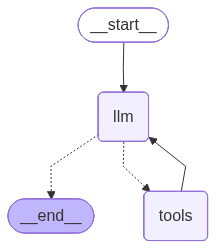

In [95]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [96]:
result = app.invoke({
    "messages": [HumanMessage(content="what is the stock price of TCS.NS?")]
})

In [97]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the stock price of TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (call_SDL9d0R3JNjOVTJhK8gDdZ0m)
 Call ID: call_SDL9d0R3JNjOVTJhK8gDdZ0m
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_stock_price

The last closing price of TCS.NS was ₹2557.60.
================================== Ai Message ==================================

The last closing price of TCS.NS was ₹2557.60.


In [98]:
result = app.invoke({
    "messages": [HumanMessage(content="what was in the latest indian union budget report of 2026?")]
})

In [99]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what was in the latest indian union budget report of 2026?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_BaRQD41UKd7VxYviLFZUgTWt)
 Call ID: call_BaRQD41UKd7VxYviLFZUgTWt
  Args:
    query: Indian Union Budget 2026
================================= Tool Message =================================
Name: wikipedia

Page: 2026 Union budget of India
Summary: The Union Budget of India for 2026–27 was presented on 1 February 2026 in the Lok Sabha by Finance Minister Nirmala Sitharaman on behalf of the Third Modi ministry. The budget outlined the Government of India's fiscal policy, taxation proposals, and expenditure priorities for the financial year 2026–27.
According to the Press Information Bureau (PIB), India's real GDP growth for 2025–26 was estimated at 7.4%, with nominal growth projected at 10% for 2026
================================== Ai M

In [100]:
result = app.invoke({
    "messages": [HumanMessage(content="give me the latest AI news count the length of response and multiply that response with the 10.")]
})

In [101]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

give me the latest AI news count the length of response and multiply that response with the 10.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_mtx6n6FaRy48AvXsiZsCk3Qc)
 Call ID: call_mtx6n6FaRy48AvXsiZsCk3Qc
  Args:
    query: Artificial Intelligence news
================================= Tool Message =================================
Name: wikipedia

Page: Applications of artificial intelligence
Summary: Artificial intelligence is the capability of the  computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. Artificial intelligence has been used in applications throughout industry and academia. Within the field of Artificial Intelligence, there are multiple subfields. The subfield of Machine learning has been used for various scientif

In [102]:
result = app.invoke({
    "messages": [HumanMessage(content="how did trump's tariff policy impact the TCS.NS?")]
})

In [103]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

how did trump's tariff policy impact the TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_u6ZRds79Lh2cLYjLYKAdpzcV)
 Call ID: call_u6ZRds79Lh2cLYjLYKAdpzcV
  Args:
    query: Trump Tariff Policy
================================= Tool Message =================================
Name: wikipedia

Page: Tariffs in the second Trump administration
Summary: During his second term as President of the United States, Donald Trump enacted a series of steep tariffs affecting nearly all goods imported into the country. From January to April 2025, the overall average effective US tariff rate rose from 2.5% to an estimated 27%—the highest level in over a century. After changes, negotiations, and the invalidation of certain tariffs by the Supreme Court of the United States, the overall average effect
================================== Ai Message ========